<a href="https://colab.research.google.com/github/MrJames509/Ciencia-de-datos/blob/main/Regresi%C3%B3n_lineal_simple_y_m%C3%BAltiple_Alumnos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#REGRESIÓN LINEAL

###Carrera: Tecnicatura Superior en Ciencia de Datos e IA

###Institución: IFTS 33 - UOCRA

###Profesora: Marisa Cánovas

## Objetivo

Realizar el modelado de Regresión Lineal con el dataset de Boston considerando:

- **Variable independiente (X)**: `Rooms` (cantidad de habitaciones)
- **Variable dependiente (y)**: `Value` (valor de la propiedad)


In [ ]:
## Paso 1: Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
## Paso 2: Cargar y explorar los datos
df = pd.read_excel('/content/Boston House Prices.xlsx')

# Exploración inicial
print("=== EXPLORACIÓN DE DATOS ===")
print("Forma del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInformación general:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())
print("\n" + "="*40 + "\n")

## Paso 3: Preparar las variables
# Extraer variables
X = df['Rooms'].values          # Variable independiente
y = df['Value'].values          # Variable dependiente

# Agregar columna de unos para el término independiente (intercepto)
X_ones = np.c_[np.ones(len(X)), X]
#np.c_[] lo apila horizontalmente al lado de X.
print(f"X_ones shape: {X_ones.shape}")
print(f"Primeras 3 filas de X_ones:\n{X_ones[:3]}")
print("\n" + "="*40 + "\n")

# Antes:              # Después (X_ones):
# Rooms               Rooms | Bias(1)
#[[6.5],                [[1.0, 6.5],
# [5.2],      ---->      [1.0, 5.2],
# [7.1]]                 [1.0, 7.1]]

print(f"X_ones shape: {X_ones.shape}")
print(f"Primeras 3 filas de X_ones:\n{X_ones[:3]}")

## Paso 4: # Calculamos los coeficientes (β) usando la solución analítica de OLS: Ordinary Least Squares (Mínimos Cuadrados Ordinarios)
coeficientes = np.linalg.inv(X_ones.T @ X_ones) @ X_ones.T @ y

# =============================================================================
#Mate:FÓRMULA: β = (X'X)⁻¹ X'y  →  Mínimos Cuadrados Ordinarios (OLS)
#Python: np.linalg.inv(X_ones.T @ X_ones) @ X_ones.T @ y
# =============================================================================

#1️⃣ X_ones.T  →  Transpuesta de X
#    Intercambia filas ↔ columnas
#    Si X_ones tiene forma (n, 2), entonces X_ones.T tiene forma (2, n)
X_ones_T = X_ones.T

# 2️⃣ X_ones.T @ X_ones  →  Producto matricial X'X
#    Crea una matriz cuadrada (2×2 en este caso)
#    Resume cómo se correlacionan las features entre sí
#XtX = X_ones.T @ X_ones

# 3️⃣ np.linalg.inv(XtX)  →  Inversa de (X'X)
#    "Despeja" los coeficientes en la ecuación normal
#     Solo funciona si la matriz es invertible (no singular)
#XtX_inv = np.linalg.inv(XtX)

# 4️⃣ X_ones.T @ y  →  Producto X'y
#    Proyecta el target (y) sobre las features (X)
#    Resultado: vector de dimensión (2,) en este caso
#Xty = X_ones.T @ y

# 5️⃣ XtX_inv @ Xty  →  Multiplicación final
#    Combina todo y entrega el vector de coeficientes β
#    Resultado: [β₀ (intercepto), β₁ (pendiente)]
#coeficientes = XtX_inv @ Xty


print(f"Coeficientes calculados:")
print(f"  Intercepto (β₀): {coeficientes[0]:.4f}")
print(f"  Pendiente (β₁):  {coeficientes[1]:.4f}")
print(f"\nEcuación del modelo: Value = {coeficientes[0]:.2f} + {coeficientes[1]:.2f} × Rooms")
print("\n" + "="*40 + "\n")

## Paso 5: Visualizar resultados
# Crear gráfico
plt.figure(figsize=(8, 6))
plt.scatter(X, y, s=40, c='#06d6a0', alpha=0.7, label='Datos reales')

# Graficar la recta de regresión
X_lim = np.array([X.min(), X.max()])
X_lim_ones = np.c_[np.ones(2), X_lim]
y_lim = X_lim_ones @ coeficientes

plt.plot(X_lim, y_lim, 'r-', linewidth=2, label='Recta de regresión')

# Personalizar
plt.xlabel('Rooms (Cantidad de habitaciones)', fontsize=11)
plt.ylabel('Value (Valor de la propiedad)', fontsize=11)
plt.title('Regresión Lineal: Rooms vs Value', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Paso 6: Hacer predicciones

# Función para predecir
#matemática y = β₀ + β₁ · x
#python:
def predecir_valor(habitaciones, coef):
    return coef[0] + coef[1] * habitaciones
#mapeo al código
#coef[0]           →  β₀ (intercepto)   # ej: -34.67
#coef[1]           →  β₁ (pendiente)    # ej:  9.10
#habitaciones      →  x (dato de entrada)

# Predicciones de ejemplo
print("=== PREDICCIONES ===")
for h in [5.0, 5.5, 6.0, 7.0]:
    pred = predecir_valor(h, coeficientes)
    print(f"Rooms = {h:.1f} → Value predicho = ${pred:.2f}")


## Paso 7: Calcular métricas de evaluación
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Predicciones para todo el dataset
y_pred = X_ones @ coeficientes

# Calcular métricas de evaluación
r2 = r2_score(y, y_pred)                    # R² (Coef. de determinación): % de variación en Y explicada por el modelo (0 a 1)
mse = mean_squared_error(y, y_pred)         # MSE (Error Cuadrático Medio): promedio de errores² → penaliza errores grandes, útil para optimización
mae = mean_absolute_error(y, y_pred)        # MAE (Error Absoluto Medio): error promedio en unidades originales → fácil de interpretar ($)
rmse = np.sqrt(mse)                         # RMSE (Raíz del MSE): vuelve a unidades originales, sensible a outliers → buen indicador de error típico

print("=== MÉTRICAS DEL MODELO ===")
print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"RMSE (Error cuadrático medio): ${rmse:.2f}")
print(f"MAE (Error absoluto medio): ${mae:.2f}")

# Interpretación
print(f"\n💡 El modelo explica el {r2*100:.2f}% de la variabilidad en el valor de las propiedades.")
df.head()

plt.xlabel('Rooms (Cantidad de habitaciones)', fontsize=11)
plt.ylabel('Value (Valor de la propiedad)', fontsize=11)
plt.title('Regresión Lineal OLS: Rooms vs Value', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# **paso 1**

In [24]:
# ## Paso 1: Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# **paso 2**

In [25]:
# ## Paso 2: Cargar y explorar los datos
df = pd.read_excel('/content/Boston House Prices.xlsx')

# Exploración inicial
print("=== EXPLORACIÓN DE DATOS ===")
print("Forma del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInformación general:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())
print("\n" + "="*40 + "\n")

=== EXPLORACIÓN DE DATOS ===
Forma del dataset: (506, 3)

Primeras 5 filas:
   Rooms  Distance  Value
0  6.575    4.0900   24.0
1  6.421    4.9671   21.6
2  7.185    4.9671   34.7
3  6.998    6.0622   33.4
4  7.147    6.0622   36.2

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Rooms     506 non-null    float64
 1   Distance  506 non-null    float64
 2   Value     506 non-null    float64
dtypes: float64(3)
memory usage: 12.0 KB
None

Estadísticas descriptivas:
            Rooms    Distance       Value
count  506.000000  506.000000  506.000000
mean     6.284634    3.795043   22.532806
std      0.702617    2.105710    9.197104
min      3.561000    1.129600    5.000000
25%      5.885500    2.100175   17.025000
50%      6.208500    3.207450   21.200000
75%      6.623500    5.188425   25.000000
max      8.780000   12.126500   50.00

# **paso 3**

In [26]:
# ## Paso 3: Preparar las variables
# Extraer variables
X = df['Rooms'].values  # Variable independiente
y = df['Value'].values  # Variable dependiente

# Agregar columna de unos para el término independiente (intercepto)
X_ones = np.c_[np.ones(len(X)), X] # np.c_[] lo apila horizontalmente al lado de X.

print(f"X_ones shape: {X_ones.shape}")
print(f"Primeras 3 filas de X_ones:\n{X_ones[:3]}")
print("\n" + "="*40 + "\n")

X_ones shape: (506, 2)
Primeras 3 filas de X_ones:
[[1.    6.575]
 [1.    6.421]
 [1.    7.185]]




# paso **4**

In [27]:
# ## Paso 4: Calculamos los coeficientes (β) usando la solución analítica de OLS: Ordinary Least Squares (Mínimos Cuadrados Ordinarios)
# Fórmula matemática: β = (X'X)⁻¹ X'y

# 1. Transpuesta de X
X_ones_T = X_ones.T

# 2. Producto matricial X'X
XtX = X_ones_T @ X_ones

# 3. Inversa de (X'X)
XtX_inv = np.linalg.inv(XtX)

# 4. Producto X'y
Xty = X_ones_T @ y

# 5. Multiplicación final para obtener el vector de coeficientes β
coeficientes = XtX_inv @ Xty

print("Coeficientes calculados:")
print(f"  Intercepto (β₀): {coeficientes[0]:.4f}")
print(f"  Pendiente (β₁):  {coeficientes[1]:.4f}")
print(f"\nEcuación del modelo: Value = {coeficientes[0]:.2f} + {coeficientes[1]:.2f} × Rooms")
print("\n" + "="*40 + "\n")

Coeficientes calculados:
  Intercepto (β₀): -34.6706
  Pendiente (β₁):  9.1021

Ecuación del modelo: Value = -34.67 + 9.10 × Rooms




# **paso 5**

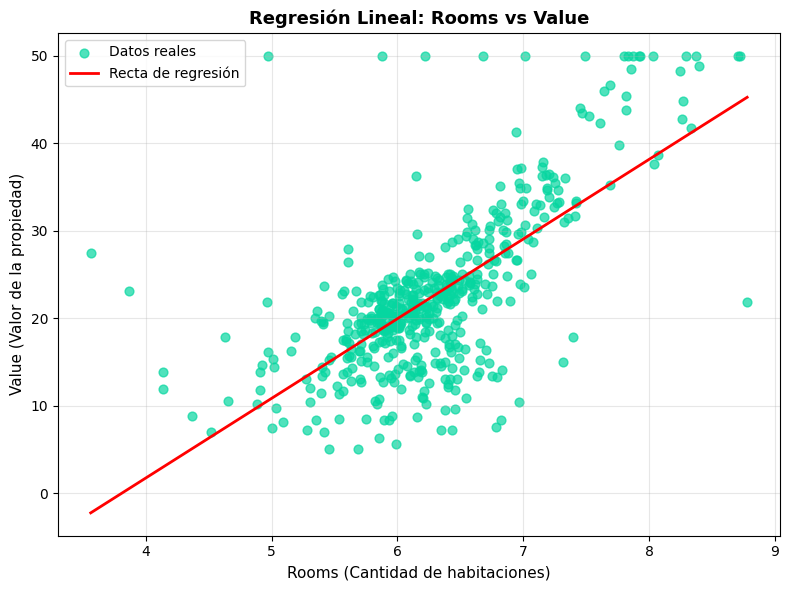

In [28]:
# ## Paso 5: Visualizar resultados
# Crear gráfico
plt.figure(figsize=(8, 6))
plt.scatter(X, y, s=40, c='#06d6a0', alpha=0.7, label='Datos reales')

# Graficar la recta de regresión
X_lim = np.array([X.min(), X.max()])
X_lim_ones = np.c_[np.ones(2), X_lim]
y_lim = X_lim_ones @ coeficientes

plt.plot(X_lim, y_lim, 'r-', linewidth=2, label='Recta de regresión')

# Personalizar
plt.xlabel('Rooms (Cantidad de habitaciones)', fontsize=11)
plt.ylabel('Value (Valor de la propiedad)', fontsize=11)
plt.title('Regresión Lineal: Rooms vs Value', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# **paso 6**

In [36]:
# ## Paso 6: Hacer predicciones

# Función para predecir basada en la matemática: y = β₀ + β₁ · x
def predecir_valor(habitaciones, coef):
    return coef[0] + coef[1] * habitaciones

# Predicciones de ejemplo
print("=== PREDICCIONES ===")
for h in [5.0, 5.5, 6.0, 7.0]:
    pred = predecir_valor(h, coeficientes)
    print(f"Rooms = {h:.1f} → Value predicho = ${pred:.2f}")


=== PREDICCIONES ===
Rooms = 5.0 → Value predicho = $10.84
Rooms = 5.5 → Value predicho = $15.39
Rooms = 6.0 → Value predicho = $19.94
Rooms = 7.0 → Value predicho = $29.04


# paso **7**

In [37]:
# ## Paso 7: Calcular métricas de evaluación

# Predicciones para todo el dataset
y_pred = X_ones @ coeficientes

# Calcular métricas cuantitativas
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mse)

print("=== MÉTRICAS DEL MODELO ===")
print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"RMSE (Error cuadrático medio):   ${rmse:.2f}")
print(f"MAE (Error absoluto medio):      ${mae:.2f}")

# Interpretación final
print(f"\n💡 El modelo explica el {r2*100:.2f}% de la variabilidad en el valor de las propiedades.")


=== MÉTRICAS DEL MODELO ===
R² (Coeficiente de determinación): 0.4835
RMSE (Error cuadrático medio):   $6.60
MAE (Error absoluto medio):      $4.45

💡 El modelo explica el 48.35% de la variabilidad en el valor de las propiedades.


#Ejercicio
Agregar otra feature para comparar
Recordás bien. Una vez que tienen el modelo con solo Rooms, el siguiente paso natural es:
Agregar otra variable (ej: Distance)
Comparar el R² para ver si mejora la predicción

##Bonus: Modelo con MÚLTIPLES features (Rooms + Distance)

In [ ]:
# Preparar X con dos features
X_multi = df[['Rooms', 'Distance']].values
X_multi_ones = np.c_[np.ones(len(X_multi)), X_multi]

# Calcular coeficientes (3 valores: β₀, β₁, β₂)
coef_multi = np.linalg.inv(X_multi_ones.T @ X_multi_ones) @ X_multi_ones.T @ y

# Evaluar
y_pred_multi = X_multi_ones @ coef_multi

# 🔹 Métricas completas
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_multi = r2_score(y, y_pred_multi)                    # R²: % variación explicada
mse_multi = mean_squared_error(y, y_pred_multi)         # MSE: error cuadrático medio
rmse_multi = np.sqrt(mse_multi)                         # RMSE: en unidades originales ($)
mae_multi = mean_absolute_error(y, y_pred_multi)        # MAE: error absoluto medio

# 📊 Mostrar resultados
print(f"\n🎯 MODELO MULTIVARIABLE (Rooms + Distance):")
print(f"   R²   = {r2_multi:.3f}  → {r2_multi*100:.1f}% de variación explicada")
print(f"   RMSE = ${rmse_multi:.2f}k  → Error típico por predicción")
print(f"   MAE  = ${mae_multi:.2f}k  → Error promedio absoluto")
print(f"   MSE  = ${mse_multi:.2f}k² → Penaliza errores grandes")
print(f"\n📐 Coeficientes:")
print(f"   β₀ (intercepto)  = {coef_multi[0]:.2f}")
print(f"   β₁ (Rooms)       = {coef_multi[1]:.2f} → Cada habitación extra: +${coef_multi[1]*1000:.0f}")
print(f"   β₂ (Distance)    = {coef_multi[2]:.2f} → Cada unidad de distancia: ${coef_multi[2]*1000:.0f}")

#Agregar el gráfico

In [31]:
# ## Bonus: Modelo con MÚLTIPLES features (Rooms + Distance)

# 1. Preparar X con dos features
X_multi = df[['Rooms', 'Distance']].values
X_multi_ones = np.c_[np.ones(len(X_multi)), X_multi]

# 2. Calcular coeficientes analíticamente (3 valores: β₀, β₁, β₂)
coef_multi = np.linalg.inv(X_multi_ones.T @ X_multi_ones) @ X_multi_ones.T @ y

# 3. Evaluar y realizar predicciones para todo el dataset
y_pred_multi = X_multi_ones @ coef_multi

# 4. Métricas completas
r2_multi = r2_score(y, y_pred_multi)
mse_multi = mean_squared_error(y, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y, y_pred_multi)

# 5. Mostrar resultados en consola
print("=== 🎯 MODELO MULTIVARIABLE (Rooms + Distance) ===")
print(f"  R²    = {r2_multi:.3f}  →  {r2_multi*100:.1f}% de variación explicada")
print(f"  RMSE  = ${rmse_multi:.2f}k  →  Error típico por predicción")
print(f"  MAE   = ${mae_multi:.2f}k   →  Error promedio absoluto")
print(f"  MSE   = ${mse_multi:.2f}k²  →  Penaliza errores grandes")

print("\nCoeficientes:")
print(f"  β₀ (intercepto) = {coef_multi[0]:.2f}")
print(f"  β₁ (Rooms)      = {coef_multi[1]:.2f}  → Cada habitación extra: +${coef_multi[1]*1000:.0f}")
print(f"  β₂ (Distance)   = {coef_multi[2]:.2f}  → Cada unidad de distancia: ${coef_multi[2]*1000:.0f}")

=== 🎯 MODELO MULTIVARIABLE (Rooms + Distance) ===
  R²    = 0.496  →  49.6% de variación explicada
  RMSE  = $6.53k  →  Error típico por predicción
  MAE   = $4.39k   →  Error promedio absoluto
  MSE   = $42.59k²  →  Penaliza errores grandes

Coeficientes:
  β₀ (intercepto) = -34.64
  β₁ (Rooms)      = 8.80  → Cada habitación extra: +$8801
  β₂ (Distance)   = 0.49  → Cada unidad de distancia: $489


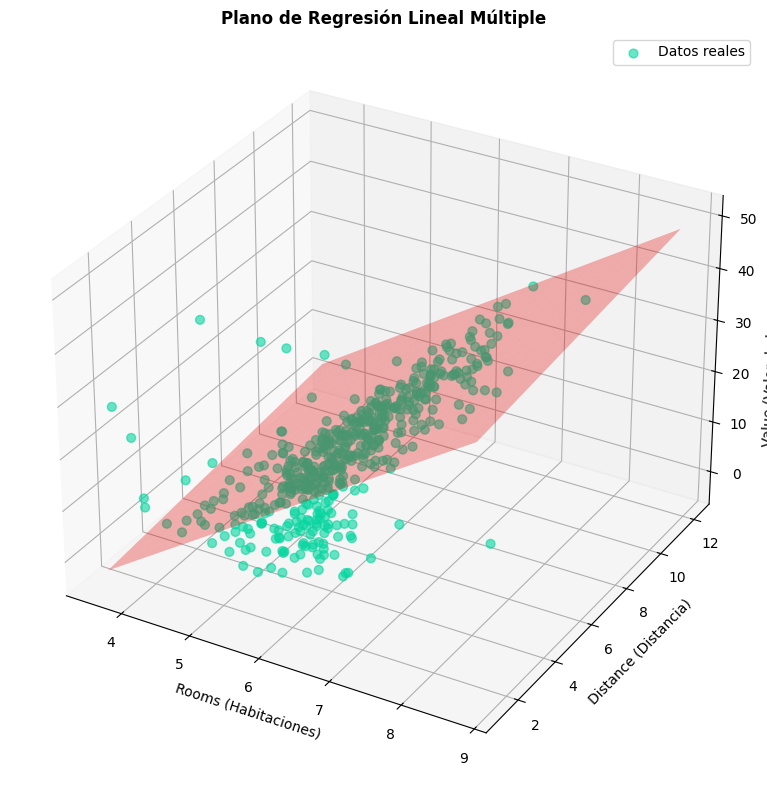

In [33]:
# ## Agregar el gráfico 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
# Corregido: add_subplot en lugar de add_sub0plot
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos (Datos reales)
ax.scatter(df['Rooms'], df['Distance'], y, c='#06d6a0', s=40, alpha=0.6, label='Datos reales')

# Crear una malla (grid) para dibujar el plano de predicción de regresión
x_range = np.linspace(df['Rooms'].min(), df['Rooms'].max(), 20)
y_range = np.linspace(df['Distance'].min(), df['Distance'].max(), 20)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# Calcular los valores predichos de 'Value' sobre la malla usando los coeficientes
Z_mesh = coef_multi[0] + coef_multi[1] * X_mesh + coef_multi[2] * Y_mesh

# Graficar el plano de regresión
ax.plot_surface(X_mesh, Y_mesh, Z_mesh, color='red', alpha=0.3, rstride=1, cstride=1)

# Personalización de etiquetas y título
ax.set_xlabel('Rooms (Habitaciones)', fontsize=10)
ax.set_ylabel('Distance (Distancia)', fontsize=10)
ax.set_zlabel('Value (Valor de la propiedad)', fontsize=10)
ax.set_title('Plano de Regresión Lineal Múltiple', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()